# Brazilian Championship (Brasileirão) 2025 — Data Analysis

**Project overview:** an end-to-end analysis of the 2025 Brazilian Série A season, turning raw CSV match data into insights on team performance, home advantage, scoring patterns, and matchday revenue.

**Tech stack:** Python · pandas · NumPy · Matplotlib · Seaborn

**Questions answered in this notebook:**

- What did the final 2025 league table look like, and how was it computed?
- How strong is home advantage in the Brazilian league?
- Who were the top scorers, and when do goals usually happen?
- Does dominating possession translate into points?
- How efficient were teams at converting shots into goals?
- Which clubs generated the most matchday revenue?


## Executive Summary

- **Champion:** Flamengo won the 2025 title with **79 points** (23W–10D–5L), the best attack (78 goals) and best defence (27 conceded).
- **Home advantage:** home teams won about **1 in 2** matches, more than double the visitors' win rate.
- **Goals:** **2.52 goals per match** on average; **Kaio Jorge** (Cruzeiro) was the league's top scorer with **21 goals**; goals peak right after half-time and in the final minutes.
- **Possession vs points:** possession correlates positively with points (**r ≈ 0.59**), but controlling the ball alone does not guarantee wins.
- **Finishing efficiency:** Flamengo combined high shot volume with strong conversion, while some teams produced high volume with low output.
- **Revenue:** Flamengo also led gross matchday revenue as the home club.

> ⚠️ **Data limitation:** the cards dataset does not cover 2025 matches, so disciplinary analysis was excluded from this version.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Render charts inline in the notebook
%matplotlib inline

# Global visual theme and default figure size
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Data Sources & Setup

The project consumes four CSV files from `datasets/`:

| File | Content |
|---|---|
| `campeonato-brasileiro-full.csv` | One row per match (date, teams, scoreline, venue, revenue, etc.) |
| `campeonato-brasileiro-estatisticas-full.csv` | Per-club, per-match statistics (shots, possession, fouls, etc.) |
| `campeonato-brasileiro-gols.csv` | One row per goal (scorer and minute) |
| `campeonato-brasileiro-cartoes.csv` | One row per card issued |

The loading routine below resolves the `datasets/` folder automatically, so the notebook works whether it is executed from the project root or from inside `notebooks/`.


In [3]:
from pathlib import Path

# Locate the "datasets" folder relative to the current working directory.
if (Path.cwd() / "datasets").exists():
    DATASETS = Path.cwd() / "datasets"
elif (Path.cwd() / ".." / "datasets").exists():
    DATASETS = (Path.cwd() / ".." / "datasets").resolve()
else:
    DATASETS = Path.cwd() / "datasets"

df_full = pd.read_csv(DATASETS / "campeonato-brasileiro-full.csv", encoding="utf-8", sep=",")
df_est = pd.read_csv(DATASETS / "campeonato-brasileiro-estatisticas-full.csv", encoding="utf-8", sep=",")
df_gols = pd.read_csv(DATASETS / "campeonato-brasileiro-gols.csv", encoding="utf-8", sep=",")
df_cartoes = pd.read_csv(DATASETS / "campeonato-brasileiro-cartoes.csv", encoding="utf-8", sep=",")

print("Files loaded successfully.")
print("Full:", df_full.shape, "| Stats:", df_est.shape, "| Goals:", df_gols.shape, "| Cards:", df_cartoes.shape)


Files loaded successfully.
Full: (9165, 17) | Stats: (18330, 13) | Goals: (10820, 6) | Cards: (20953, 8)


## 2. Data Overview & Quality Checks

Before any analysis, we inspect the structure and integrity of the main dataset:

- How many matches and columns are there?
- What are the data types of each column?
- Are there missing values or duplicate rows?


In [4]:
print("Shape (rows, columns):", df_full.shape)
print()
print("Columns:")
print(df_full.columns.tolist())

df_full.head()


Shape (rows, columns): (9165, 17)

Columns:
['ID', 'rodata', 'data', 'hora', 'mandante', 'visitante', 'formacao_mandante', 'formacao_visitante', 'tecnico_mandante', 'tecnico_visitante', 'vencedor', 'arena', 'mandante_Placar', 'visitante_Placar', 'mandante_Estado', 'visitante_Estado', 'arrecadacao']


,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN


In [5]:
# Summary: row/column counts and the dtype of each column
df_full.info()

print()
print("Data types by column:")
print(df_full.dtypes)


<class 'pandas.DataFrame'>
RangeIndex: 9165 entries, 0 to 9164
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  9165 non-null   int64  
 1   rodata              9165 non-null   int64  
 2   data                9165 non-null   str    
 3   hora                9165 non-null   str    
 4   mandante            9165 non-null   str    
 5   visitante           9165 non-null   str    
 6   formacao_mandante   4190 non-null   str    
 7   formacao_visitante  4190 non-null   str    
 8   tecnico_mandante    4555 non-null   str    
 9   tecnico_visitante   4555 non-null   str    
 10  vencedor            9165 non-null   str    
 11  arena               9165 non-null   str    
 12  mandante_Placar     9165 non-null   int64  
 13  visitante_Placar    9165 non-null   int64  
 14  mandante_Estado     9165 non-null   str    
 15  visitante_Estado    9165 non-null   str    
 16  arrecadacao      

In [6]:
# Missing values per column (only columns that actually have any)
nulls = df_full.isnull().sum()
print("Missing values by column:")
print(nulls[nulls > 0])

# Duplicate rows
print()
print("Duplicate rows:", df_full.duplicated().sum())


Missing values by column:
formacao_mandante     4975
formacao_visitante    4975
tecnico_mandante      4610
tecnico_visitante     4610
arrecadacao           8785
dtype: int64

Duplicate rows: 0


### Initial Findings

- The main file contains **9,165 matches** and **17 columns**, covering the 2003–2025 period.
- Several numeric columns (`mandante_Placar`, `visitante_Placar`, `arrecadacao`) were read as text and must be converted.
- Formation and manager columns are mostly empty for older seasons, when that information was not recorded.
- **No duplicate rows** were found.


## 3. Data Cleaning & Preparation

We transform the raw columns into analysis-ready types:

1. `data` → parse from `dd/mm/yyyy` text into a `datetime`;
2. `mandante_Placar`, `visitante_Placar`, `arrecadacao` → parse text into numeric values;
3. Create a `ano` (year) column to filter a specific season.


In [7]:
# Date: text -> datetime
df_full["data"] = pd.to_datetime(df_full["data"], format="%d/%m/%Y", errors="coerce")

# Year column, used to filter the target season
df_full["ano"] = df_full["data"].dt.year

# Scoreline and revenue: text -> numeric
df_full["mandante_Placar"] = pd.to_numeric(df_full["mandante_Placar"], errors="coerce")
df_full["visitante_Placar"] = pd.to_numeric(df_full["visitante_Placar"], errors="coerce")
df_full["arrecadacao"] = pd.to_numeric(df_full["arrecadacao"], errors="coerce")

print("Season coverage:", int(df_full["ano"].min()), "-", int(df_full["ano"].max()))
print("Total matches after cleaning:", len(df_full))


Season coverage: 2003 - 2025
Total matches after cleaning: 9165


## 4. Filtering the 2025 Season

We isolate the 2025 matches. The result is **380 matches** — exactly what is expected for a 20-team, double round-robin league (20 clubs × 38 rounds ÷ 2).


In [8]:
df_2025 = df_full[df_full["ano"] == 2025].copy()

clubes = sorted(set(df_2025["mandante"]) | set(df_2025["visitante"]))
print("2025 shape (matches, columns):", df_2025.shape)
print("Number of clubs:", len(clubes))
print("Clubs:", clubes)


2025 shape (matches, columns): (380, 18)
Number of clubs: 20
Clubs: ['Atletico-MG', 'Bahia', 'Botafogo-RJ', 'Bragantino', 'Ceara', 'Corinthians', 'Cruzeiro', 'Flamengo', 'Fluminense', 'Fortaleza', 'Gremio', 'Internacional', 'Juventude', 'Mirassol', 'Palmeiras', 'Santos', 'Sao Paulo', 'Sport', 'Vasco', 'Vitoria']


In [9]:
# Consistency check: does the "vencedor" (winner) column match the scoreline?
def winner_from_score(row):
    if row["mandante_Placar"] > row["visitante_Placar"]:
        return row["mandante"]
    if row["mandante_Placar"] < row["visitante_Placar"]:
        return row["visitante"]
    return "-"  # draw

inconsistencies = (df_2025["vencedor"] != df_2025.apply(winner_from_score, axis=1)).sum()
print("Inconsistencies between 'vencedor' and the scoreline:", inconsistencies)


Inconsistencies between 'vencedor' and the scoreline: 0


### Preparing the Auxiliary Datasets (Stats & Goals)

The stats and goals tables link to the main table via `partida_id`. We filter them to 2025 matches and parse the percentage columns (`posse_de_bola`, `precisao_passes`), which arrive as text with a `%` suffix.


In [10]:
ids_2025 = df_2025["ID"].unique()

df_est_2025 = df_est[df_est["partida_id"].isin(ids_2025)].copy()
df_gols_2025 = df_gols[df_gols["partida_id"].isin(ids_2025)].copy()

# Percentages: text '35%' -> number 35
df_est_2025["posse_de_bola"] = pd.to_numeric(
    df_est_2025["posse_de_bola"].astype(str).str.replace("%", "", regex=False), errors="coerce"
)
df_est_2025["precisao_passes"] = pd.to_numeric(
    df_est_2025["precisao_passes"].astype(str).str.replace("%", "", regex=False), errors="coerce"
)

print("2025 stats:", df_est_2025.shape, "| 2025 goals:", df_gols_2025.shape)
df_est_2025.head()


2025 stats: (760, 13) | 2025 goals: (959, 6)


,partida_id,rodata,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios
17570,8786,1,Juventude,6,4,35.0,277,90.0,17,3,0,0,3
17571,8786,1,Vitoria,9,4,64.0,479,92.0,15,4,0,0,5
17572,8787,1,Fluminense,15,1,69.0,98,NaN,5,0,0,1,5
17573,8787,1,Fortaleza,6,4,31.0,0,NaN,16,1,0,4,4
17574,8790,1,Mirassol,13,7,56.0,411,89.0,21,3,0,2,6


### Why Cards Are Excluded

The `campeonato-brasileiro-cartoes.csv` file has **no records for the 2025 match IDs** (its coverage ends before 2025). The disciplinary angle is therefore left out of this analysis, and the gap is documented below for transparency.


In [11]:
print("Total cards loaded:", len(df_cartoes))
print("Match ID range covered by the cards file:", df_cartoes["partida_id"].min(), "to", df_cartoes["partida_id"].max())
print("Match ID range for 2025:", df_2025["ID"].min(), "to", df_2025["ID"].max())
print("Cards in 2025 matches:", df_cartoes[df_cartoes["partida_id"].isin(ids_2025)].shape[0])


Total cards loaded: 20953
Match ID range covered by the cards file: 4607 to 8785
Match ID range for 2025: 8786 to 9165
Cards in 2025 matches: 0


## 5. Final 2025 Standings

The Brazilian league uses a standard **round-robin points system**:

- **Win** = 3 points
- **Draw** = 1 point
- **Loss** = 0 points

The helper below iterates over every match and accumulates, for each club: games (P), wins (W), draws (D), losses (L), goals for (GF), goals against (GA), and points. Tie-breakers applied (simplified): points → wins → goal difference → goals for.


In [12]:
def calculate_standings(matches):
    """Build the round-robin league table from match rows.

    Expects columns: mandante, visitante, mandante_Placar, visitante_Placar.
    """
    clubs = sorted(set(matches["mandante"]) | set(matches["visitante"]))

    table = {
        club: {"P": 0, "W": 0, "D": 0, "L": 0, "GF": 0, "GA": 0, "Pts": 0}
        for club in clubs
    }

    for _, game in matches.iterrows():
        home = game["mandante"]
        away = game["visitante"]
        goals_home = game["mandante_Placar"]
        goals_away = game["visitante_Placar"]

        # Games played
        table[home]["P"] += 1
        table[away]["P"] += 1

        # Goals for and against
        table[home]["GF"] += goals_home
        table[home]["GA"] += goals_away
        table[away]["GF"] += goals_away
        table[away]["GA"] += goals_home

        # Result and points
        if goals_home > goals_away:
            table[home]["W"] += 1
            table[home]["Pts"] += 3
            table[away]["L"] += 1
        elif goals_home < goals_away:
            table[away]["W"] += 1
            table[away]["Pts"] += 3
            table[home]["L"] += 1
        else:
            table[home]["D"] += 1
            table[away]["D"] += 1
            table[home]["Pts"] += 1
            table[away]["Pts"] += 1

    standings = pd.DataFrame(table).T
    standings["GD"] = standings["GF"] - standings["GA"]
    standings = standings.sort_values(
        ["Pts", "W", "GD", "GF"], ascending=[False, False, False, False]
    )
    return standings


In [13]:
standings_2025 = calculate_standings(df_2025)

# Full 2025 Brasileirao table
standings_2025[["P", "W", "D", "L", "GF", "GA", "GD", "Pts"]]


,P,W,D,L,GF,GA,GD,Pts
Flamengo,38,23,10,5,78,27,51,79
Palmeiras,38,23,7,8,66,33,33,76
Cruzeiro,38,19,13,6,55,31,24,70
Mirassol,38,18,13,7,63,39,24,67
Fluminense,38,19,7,12,50,39,11,64
Botafogo-RJ,38,17,12,9,58,38,20,63
Bahia,38,17,9,12,50,46,4,60
Sao Paulo,38,14,9,15,43,47,-4,51
Gremio,38,13,10,15,47,50,-3,49
Bragantino,38,14,6,18,45,57,-12,48


Flamengo finished as **2025 champions** with **79 points** (23W–10D–5L), ahead of Palmeiras (76) and Cruzeiro (70).

At the bottom, the relegated four were **Ceará (43), Fortaleza (43), Juventude (35)** and **Sport (17)**.

The top 10 by points:


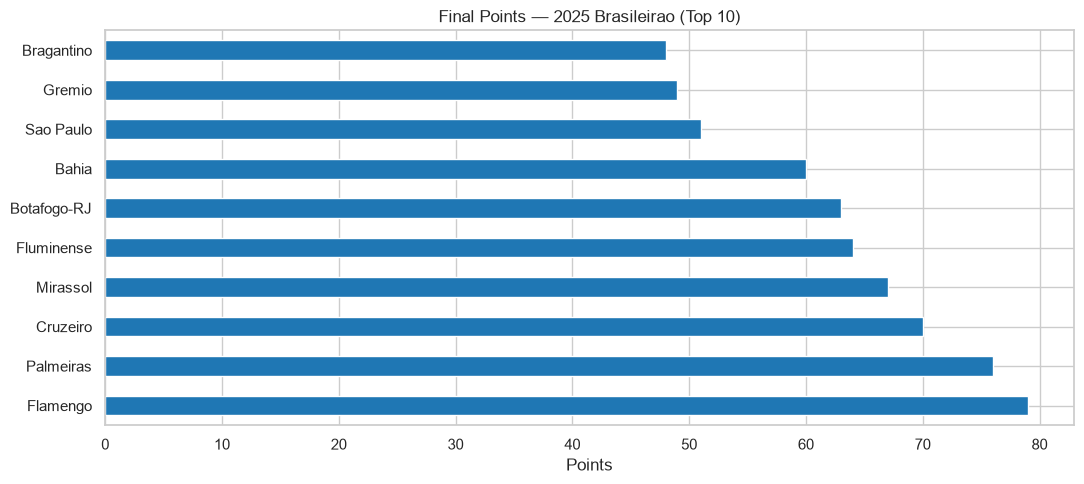

In [14]:
top10 = standings_2025[["Pts"]].head(10).sort_values("Pts")

ax = top10.plot(kind="barh", legend=False, color="#1f77b4")
ax.set_title("Final Points — 2025 Brasileirao (Top 10)")
ax.set_xlabel("Points")
ax.invert_yaxis()  # first place at the top
plt.tight_layout()
plt.show()


## 6. Home Advantage

Playing at home typically brings a measurable edge. We quantify it by looking at outcomes from the home team's perspective.


Home wins : 191 (50.3%)
Draws     : 99 (26.1%)
Away wins : 90 (23.7%)


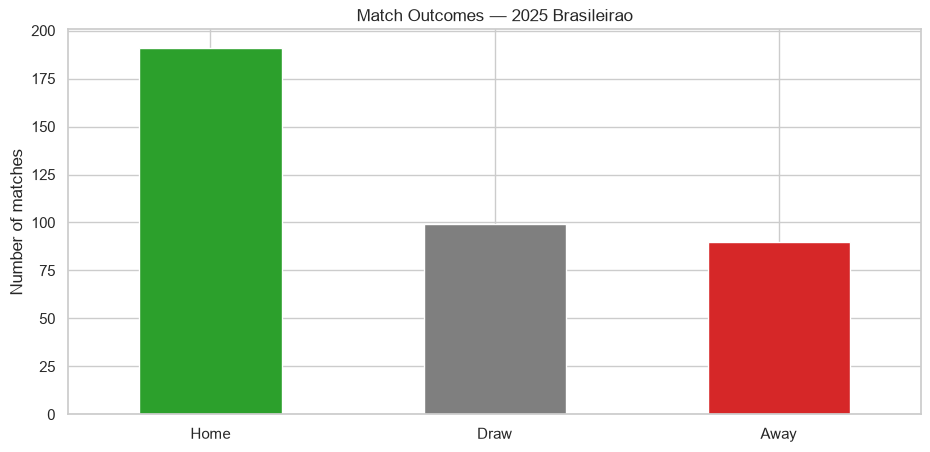

In [15]:
n_games = len(df_2025)
home_wins = (df_2025["mandante_Placar"] > df_2025["visitante_Placar"]).sum()
draws = (df_2025["mandante_Placar"] == df_2025["visitante_Placar"]).sum()
away_wins = (df_2025["mandante_Placar"] < df_2025["visitante_Placar"]).sum()

print(f"Home wins : {home_wins} ({home_wins / n_games * 100:.1f}%)")
print(f"Draws     : {draws} ({draws / n_games * 100:.1f}%)")
print(f"Away wins : {away_wins} ({away_wins / n_games * 100:.1f}%)")

results = pd.Series(
    [home_wins, draws, away_wins],
    index=["Home", "Draw", "Away"],
)
results.plot(kind="bar", color=["#2ca02c", "#7f7f7f", "#d62728"])
plt.title("Match Outcomes — 2025 Brasileirao")
plt.ylabel("Number of matches")
plt.xticks(rotation=0)
plt.show()


In 2025 **home teams won roughly half of all matches**, while away teams won about one in four. Home advantage effectively **doubled** a team's chance of victory — a strong, well-known pattern in football.


## 7. Goals Analysis

We answer:

- How many goals were scored in 2025, and what was the average per match?
- Who were the top scorers?
- What types of goal occurred (open play, penalty, own goal)?
- When during a match do goals tend to happen?


In [16]:
total_goals = int(df_2025["mandante_Placar"].sum() + df_2025["visitante_Placar"].sum())
avg_goals = total_goals / len(df_2025)

print(f"Total goals in 2025: {total_goals}")
print(f"Average goals per match: {avg_goals:.2f}")


Total goals in 2025: 959
Average goals per match: 2.52


In [17]:
top_scorers = (
    df_gols_2025.groupby(["clube", "atleta"])
    .size()
    .reset_index(name="goals")
    .sort_values("goals", ascending=False)
)

print("Top scorers — 2025 Brasileirao (top 15):")
top_scorers.head(15)


Top scorers — 2025 Brasileirao (top 15):


,clube,atleta,goals
115,Cruzeiro,Kaio Jorge,21
131,Flamengo,Giorgian de Arrascaeta,18
265,Palmeiras,Vitor Roque,16
324,Vasco,Pablo Vegetti,14
328,Vasco,Rayan,14
245,Mirassol,Reinaldo Manoel da Silva,13
256,Palmeiras,José Manuel Alberto López,12
141,Flamengo,Pedro,12
188,Gremio,Carlos Vinícius,12
38,Bahia,Willian José,11


tipo
Gol normal    849
Penalty        90
Gol Contra     20
Name: count, dtype: int64


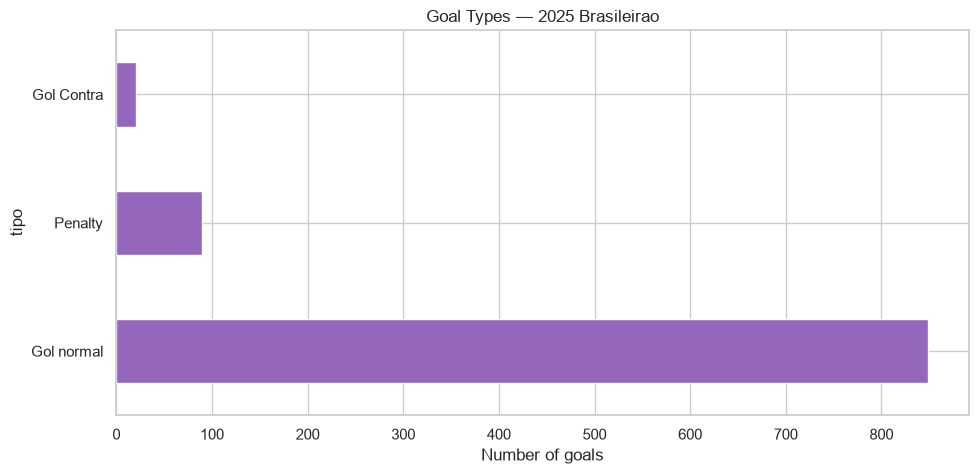

In [18]:
# "tipo_de_gol" is empty for open-play goals; we label those explicitly
df_gols_2025["tipo"] = df_gols_2025["tipo_de_gol"].fillna("Gol normal")

goal_types = df_gols_2025["tipo"].value_counts()
print(goal_types)

goal_types.plot(kind="barh", color="#9467bd")
plt.title("Goal Types — 2025 Brasileirao")
plt.xlabel("Number of goals")
plt.show()


To analyse *when* goals are scored, the minute column is parsed from text — e.g. `"45+3"` means the 48th minute (45 + 3 stoppage time) — then goals are grouped into 15-minute buckets.

> **Note:** first-half stoppage-time goals (45+X) fall into the 46–60 bucket because the minute is computed as 45+X.


Goals by minute bucket:
bucket
1-15     126
16-30    128
31-45    132
46-60    196
61-75    151
76-90    152
90+       74
Name: count, dtype: int64


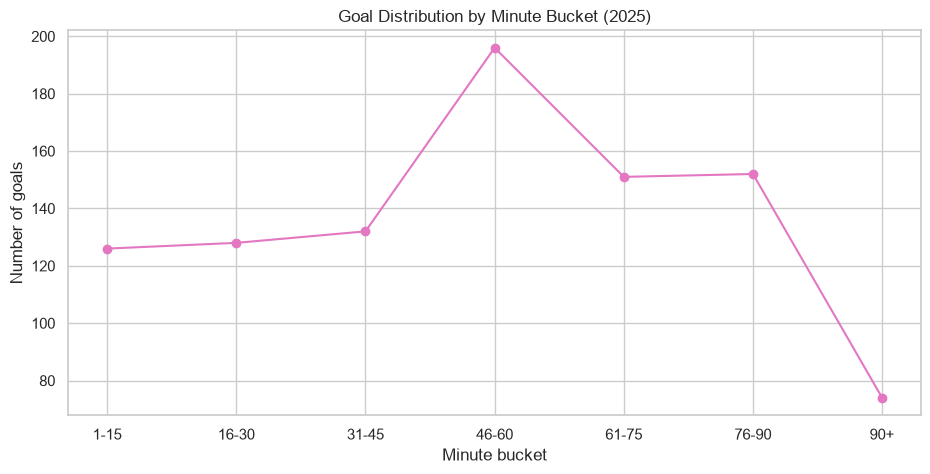

In [19]:
def minute_to_number(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if "+" in text:
        base, stoppage = text.split("+")
        return int(base) + int(stoppage)
    return int(text)

df_gols_2025["minute_num"] = df_gols_2025["minuto"].apply(minute_to_number)

bins = [0, 15, 30, 45, 60, 75, 90, 200]
labels = ["1-15", "16-30", "31-45", "46-60", "61-75", "76-90", "90+"]

with_minute = df_gols_2025.dropna(subset=["minute_num"]).copy()
with_minute["bucket"] = pd.cut(
    with_minute["minute_num"], bins=bins, labels=labels, right=True
)

goals_by_bucket = with_minute["bucket"].value_counts().reindex(labels)
print("Goals by minute bucket:")
print(goals_by_bucket)

goals_by_bucket.plot(kind="line", marker="o", color="#e377c2")
plt.title("Goal Distribution by Minute Bucket (2025)")
plt.xlabel("Minute bucket")
plt.ylabel("Number of goals")
plt.grid(True)
plt.show()


Goals are not evenly distributed: there is a **peak just after half-time (46–60')** and another **late in the game (76–90+)**. Tactically this makes sense — teams return from the break with adjustments and intensity, and matches open up in the closing stages.

By type, the large majority were **open-play goals**; **penalties** accounted for 90 and **own goals** for 20.


## 8. Ball Possession vs Points

We compute each club's **average possession** and compare it to final points using the **Pearson correlation**:

- Close to **+1** → variables move together;
- Close to **0** → no clear relationship;
- Close to **−1** → inverse relationship.


Average possession by club (top 10, %):
clube
Flamengo       60.9
Bahia          55.1
Corinthians    55.0
Vasco          54.6
Fluminense     52.6
Palmeiras      52.4
Mirassol       52.1
Atletico-MG    51.9
Botafogo-RJ    51.9
Sao Paulo      51.8
Name: posse_de_bola, dtype: float64

Correlation between average possession and points: 0.59


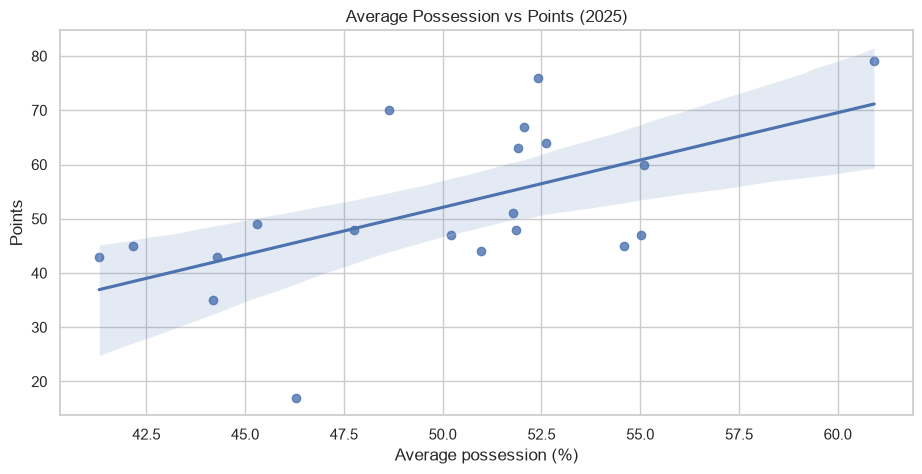

In [20]:
possession_avg = df_est_2025.groupby("clube")["posse_de_bola"].mean().round(1).sort_values(ascending=False)

print("Average possession by club (top 10, %):")
print(possession_avg.head(10))

relationship = pd.DataFrame({
    "possession_avg": df_est_2025.groupby("clube")["posse_de_bola"].mean(),
    "points": standings_2025["Pts"],
})

correlation = relationship["possession_avg"].corr(relationship["points"])
print(f"\nCorrelation between average possession and points: {correlation:.2f}")

sns.regplot(x="possession_avg", y="points", data=relationship)
plt.title("Average Possession vs Points (2025)")
plt.xlabel("Average possession (%)")
plt.ylabel("Points")
plt.show()


The correlation is around **0.59**: positive and meaningful, but far from perfect. In practice, **controlling possession helps, but does not guarantee results** — some sides dominate the ball and accumulate few points, and vice-versa. Possession must be read alongside metrics such as finishing.


## 9. Finishing & Goal Conversion

Not every shot becomes a goal. Two related metrics:

- **Shot accuracy** = shots on target ÷ total shots;
- **Conversion rate** = goals scored ÷ total shots.


In [21]:
shots = df_est_2025.groupby("clube")[["chutes", "chutes_no_alvo"]].sum()
goals_by_club = df_gols_2025.groupby("clube").size().rename("goals")

conversion = pd.DataFrame({
    "shots": shots["chutes"],
    "shots_on_target": shots["chutes_no_alvo"],
    "goals": goals_by_club,
})
conversion["shot_accuracy_%"] = (conversion["shots_on_target"] / conversion["shots"] * 100).round(1)
conversion["goal_conversion_%"] = (conversion["goals"] / conversion["shots"] * 100).round(1)

conversion.sort_values("shots", ascending=False)


,shots,shots_on_target,goals,shot_accuracy_%,goal_conversion_%
clube,,,,,
Flamengo,531,199,78,37.5,14.7
Palmeiras,514,197,66,38.3,12.8
Atletico-MG,513,166,43,32.4,8.4
Botafogo-RJ,501,191,58,38.1,11.6
Santos,478,156,45,32.6,9.4
Internacional,475,176,44,37.1,9.3
Bahia,471,168,50,35.7,10.6
Cruzeiro,469,182,55,38.8,11.7
Fortaleza,464,162,43,34.9,9.3


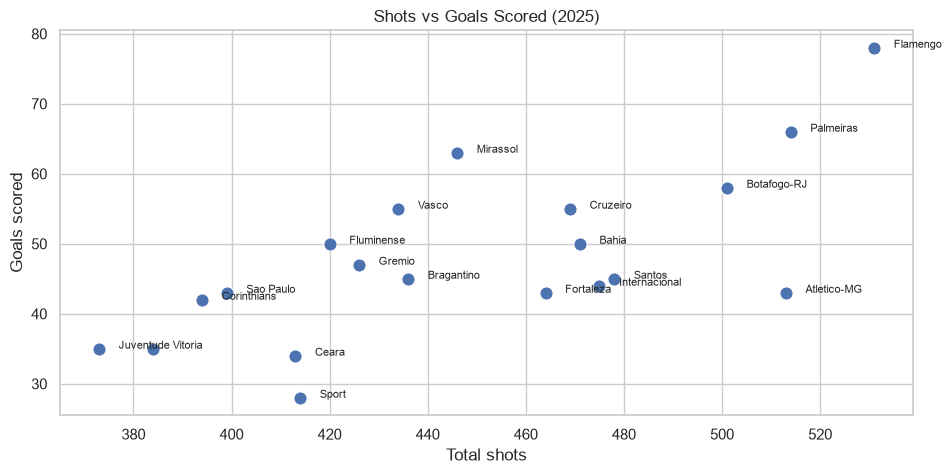

In [22]:
ax = sns.scatterplot(data=conversion, x="shots", y="goals", s=90)
for club, row in conversion.iterrows():
    ax.text(row["shots"] + 4, row["goals"], club, fontsize=8)

ax.set_title("Shots vs Goals Scored (2025)")
ax.set_xlabel("Total shots")
ax.set_ylabel("Goals scored")
plt.show()


The chart shows that while **more shots generally lead to more goals**, efficiency varies widely. Flamengo sits in the top-right corner (high volume, high output), while some clubs produced a high shot count with far fewer goals — a clear sign of low efficiency.


## 10. Matchday Revenue by Club

The `arrecadacao` column holds the **gross** amount collected by the home club per match (before taxes and deductions). We aggregate it by home club.


Gross home matchday revenue (top 10, in BRL):
mandante
Flamengo       81773984.00
Corinthians    54079722.40
Palmeiras      47680681.00
Cruzeiro       44959741.96
Vasco          30996515.50
Sao Paulo      28598317.50
Gremio         26960631.00
Bahia          26505687.00
Fluminense     24651439.50
Atletico-MG    24078786.16
Name: arrecadacao, dtype: float64

Average revenue per match: R$ 1,363,329.52


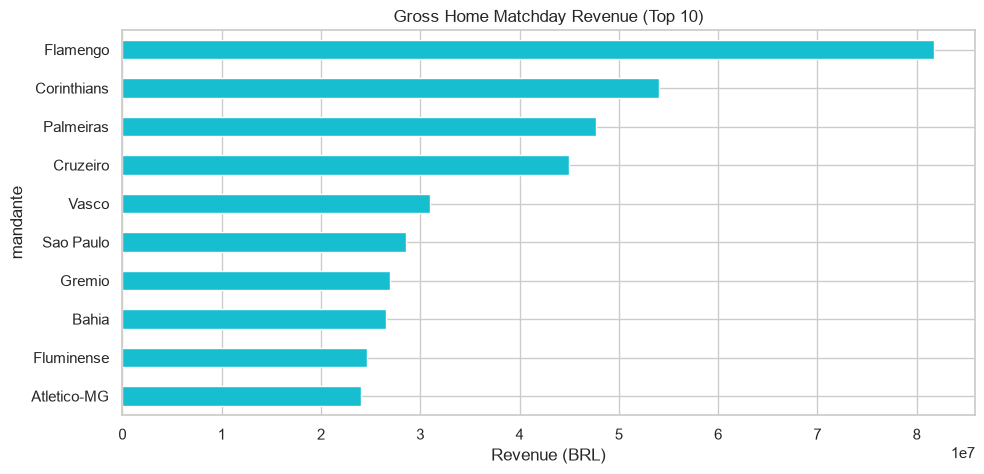

In [23]:
revenue_by_club = (
    df_2025.groupby("mandante")["arrecadacao"]
    .sum()
    .sort_values(ascending=False)
)

print("Gross home matchday revenue (top 10, in BRL):")
print(revenue_by_club.head(10).round(2))

avg_per_match = df_2025["arrecadacao"].mean()
print(f"\nAverage revenue per match: R$ {avg_per_match:,.2f}")

revenue_by_club.head(10).sort_values().plot(kind="barh", color="#17becf")
plt.title("Gross Home Matchday Revenue (Top 10)")
plt.xlabel("Revenue (BRL)")
plt.show()


Flamengo also topped the gross home matchday revenue table — consistent with a title-winning season and a strong home following.


## 11. Conclusions

- **Champion:** Flamengo won with **79 points**, pairing the best attack (78 goals) with the best defence (27 conceded).
- **Home advantage:** home wins outnumbered away wins by more than 2-to-1.
- **Goals:** ~2.52 per match; top scorer **Kaio Jorge** (Cruzeiro, 21 goals); scoring peaks after the break and late in matches.
- **Possession:** positively correlated with points (~0.59) but not decisive on its own.
- **Finishing:** Flamengo led shot volume with strong conversion — raw shot volume without efficiency is not enough.
- **Revenue:** Flamengo also led gross home matchday revenue.

**Known limitation:** the cards dataset does not cover 2025, so the disciplinary analysis was omitted.
